# 01. Exploratory Data Analysis (EDA)
## Household Power Consumption Dataset

**Objectives:**
- Load and inspect the raw dataset
- Analyze data quality (missing values, duplicates, outliers)
- Visualize temporal patterns and distributions
- Generate summary statistics

In [19]:
# Import libraries
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import PowerDataLoader
from src.visualization.plots import PowerVisualizer

import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Data

In [20]:
# Initialize loader with explicit config path
config_path = '../configs/params.yaml'
loader = PowerDataLoader(config_path=config_path)

# Load raw data with explicit path from notebooks directory
data_path = '../data/raw/household_power_consumption.txt'
df_raw = loader.load_raw_data(file_path=data_path)

print(f"\nDataset shape: {df_raw.shape}")
print(f"Date range: {df_raw.index.min()} to {df_raw.index.max()}")
print(f"\nFirst few rows:")

# Display dataframe
df_raw.head()

Loading data from ../data/raw/household_power_consumption.txt...
Loaded 2075259 rows, 7 columns
Date range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00

Dataset shape: (2075259, 7)
Date range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00

First few rows:


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


## 2. Data Quality Assessment

In [21]:
# Get data info
info = loader.get_data_info()

print("=" * 80)
print("DATA INFORMATION")
print("=" * 80)
print(f"Number of rows: {info['n_rows']:,}")
print(f"Number of columns: {info['n_columns']}")
print(f"Date range: {info['date_range'][0]} to {info['date_range'][1]}")
print(f"Memory usage: {info['memory_usage_mb']:.2f} MB")
print("\nData types:")
for col, dtype in info['dtypes'].items():
    print(f"  {col}: {dtype}")

DATA INFORMATION
Number of rows: 2,075,259
Number of columns: 7
Date range: 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Memory usage: 126.66 MB

Data types:
  Global_active_power: float64
  Global_reactive_power: float64
  Voltage: float64
  Global_intensity: float64
  Sub_metering_1: float64
  Sub_metering_2: float64
  Sub_metering_3: float64


In [22]:
# Missing values analysis
print("\n" + "=" * 80)
print("MISSING VALUES")
print("=" * 80)

missing_df = pd.DataFrame({
    'Column': info['missing_by_column'].keys(),
    'Missing Count': info['missing_by_column'].values(),
    'Missing %': [f"{v:.2f}%" for v in info['missing_percentage'].values()]
})

print(missing_df.to_string(index=False))


MISSING VALUES
               Column  Missing Count Missing %
  Global_active_power          25979     1.25%
Global_reactive_power          25979     1.25%
              Voltage          25979     1.25%
     Global_intensity          25979     1.25%
       Sub_metering_1          25979     1.25%
       Sub_metering_2          25979     1.25%
       Sub_metering_3          25979     1.25%


In [23]:
# Basic statistics
print("\n" + "=" * 80)
print("DESCRIPTIVE STATISTICS")
print("=" * 80)
df_raw.describe()


DESCRIPTIVE STATISTICS


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01


## 3. Temporal Analysis

Saved figure to outputs\figures\01_time_series_full.png


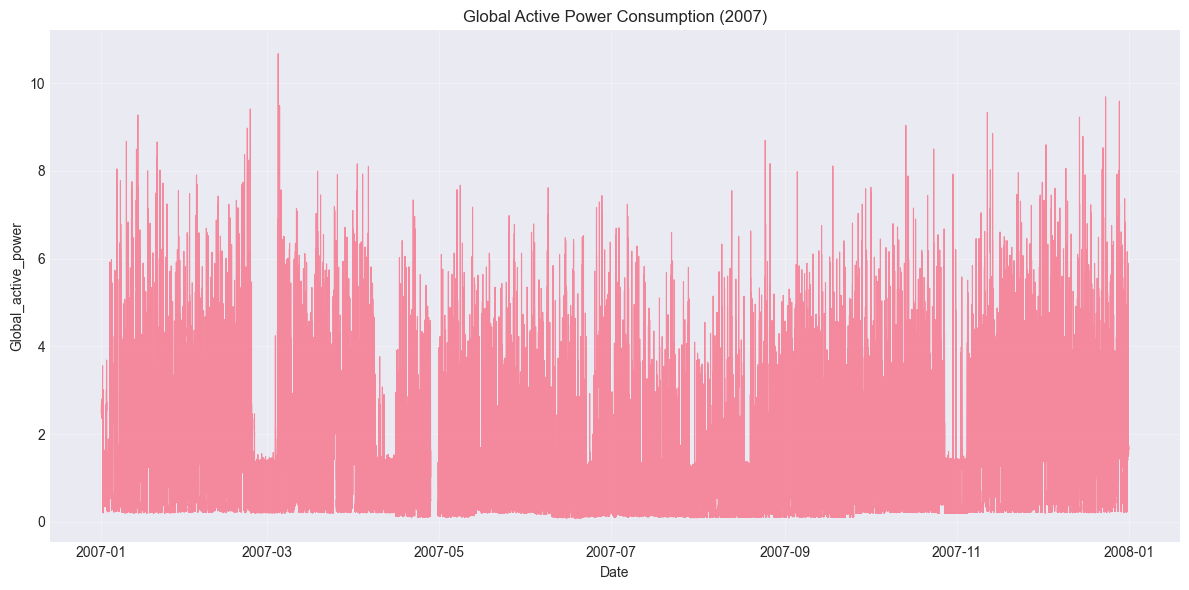

In [24]:
# Initialize visualizer
viz = PowerVisualizer(config_path='../configs/params.yaml')

# Plot full time series (sample for performance)
df_sample = df_raw['2007-01':'2007-12']  # Sample one year

viz.plot_time_series(
    df_sample,
    column='Global_active_power',
    title='Global Active Power Consumption (2007)',
    filename='01_time_series_full.png'
)
plt.show()

Saved figure to outputs\figures\01_time_series_daily.png


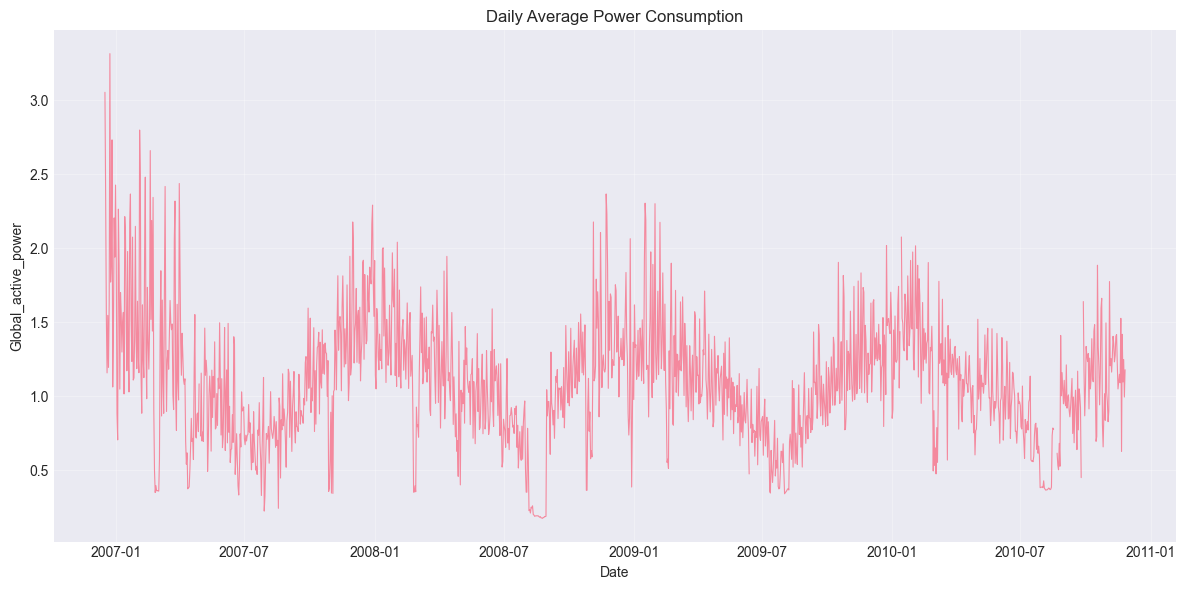

In [25]:
# Aggregate to daily and plot
df_daily = df_raw.resample('D').mean()

viz.plot_time_series(
    df_daily,
    column='Global_active_power',
    title='Daily Average Power Consumption',
    filename='01_time_series_daily.png'
)
plt.show()

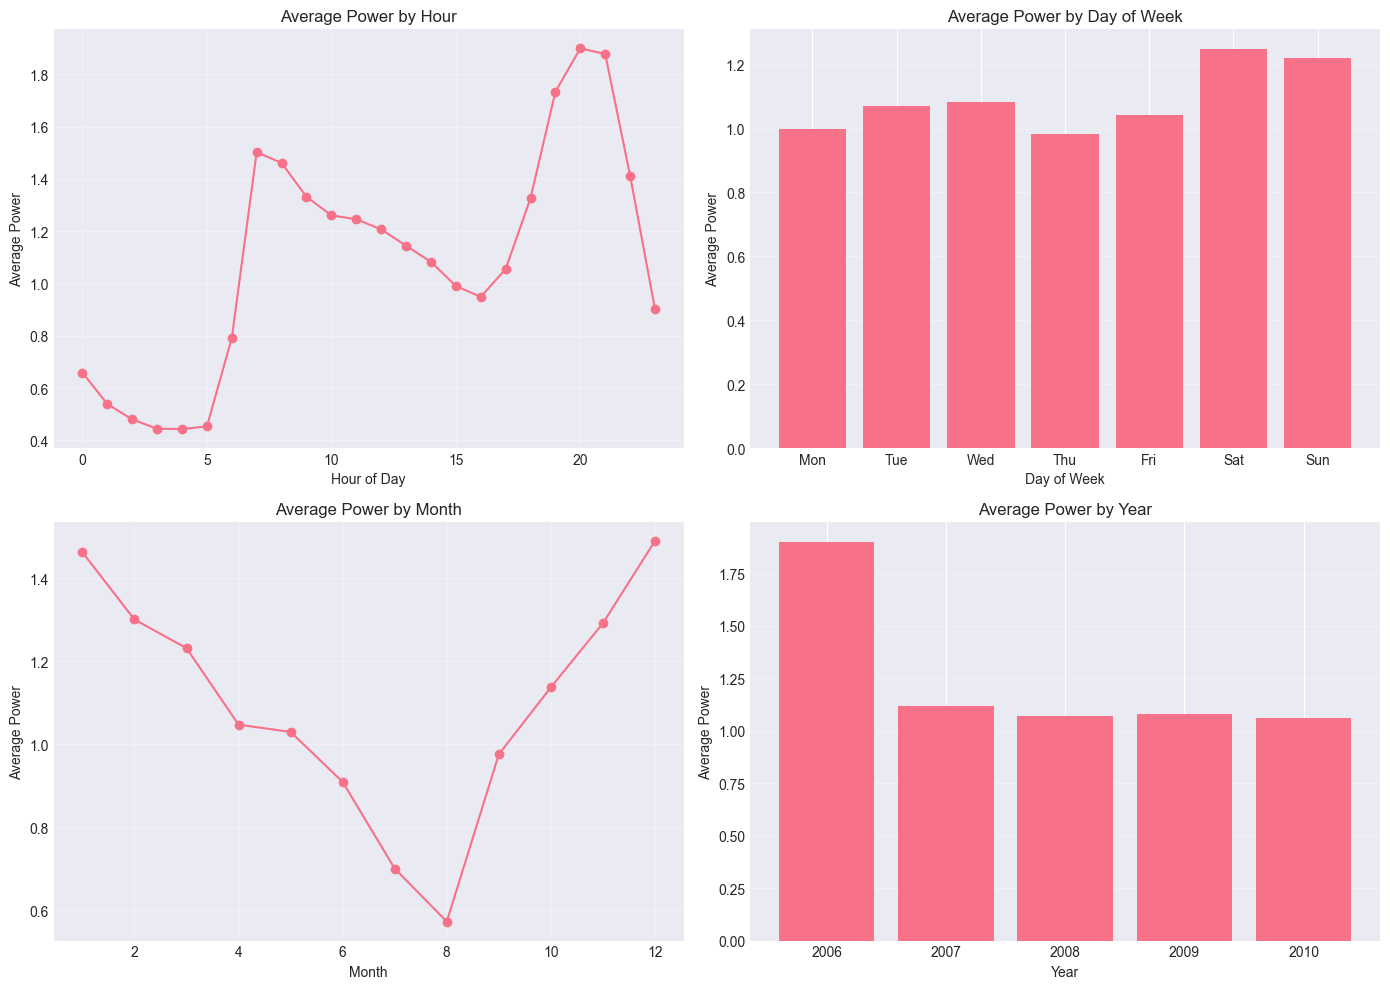

In [26]:
# Seasonal patterns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Hourly pattern
hourly_avg = df_raw.groupby(df_raw.index.hour)['Global_active_power'].mean()
axes[0, 0].plot(hourly_avg.index, hourly_avg.values, marker='o')
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Average Power')
axes[0, 0].set_title('Average Power by Hour')
axes[0, 0].grid(True, alpha=0.3)

# Day of week pattern
dow_avg = df_raw.groupby(df_raw.index.dayofweek)['Global_active_power'].mean()
axes[0, 1].bar(range(7), dow_avg.values)
axes[0, 1].set_xlabel('Day of Week')
axes[0, 1].set_ylabel('Average Power')
axes[0, 1].set_title('Average Power by Day of Week')
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Monthly pattern
monthly_avg = df_raw.groupby(df_raw.index.month)['Global_active_power'].mean()
axes[1, 0].plot(monthly_avg.index, monthly_avg.values, marker='o')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Average Power')
axes[1, 0].set_title('Average Power by Month')
axes[1, 0].grid(True, alpha=0.3)

# Yearly pattern
yearly_avg = df_raw.groupby(df_raw.index.year)['Global_active_power'].mean()
axes[1, 1].bar(yearly_avg.index, yearly_avg.values)
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Average Power')
axes[1, 1].set_title('Average Power by Year')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../outputs/figures/01_seasonal_patterns.png', dpi=100, bbox_inches='tight')
plt.show()

## 4. Distribution Analysis

Saved figure to outputs\figures\01_distributions.png


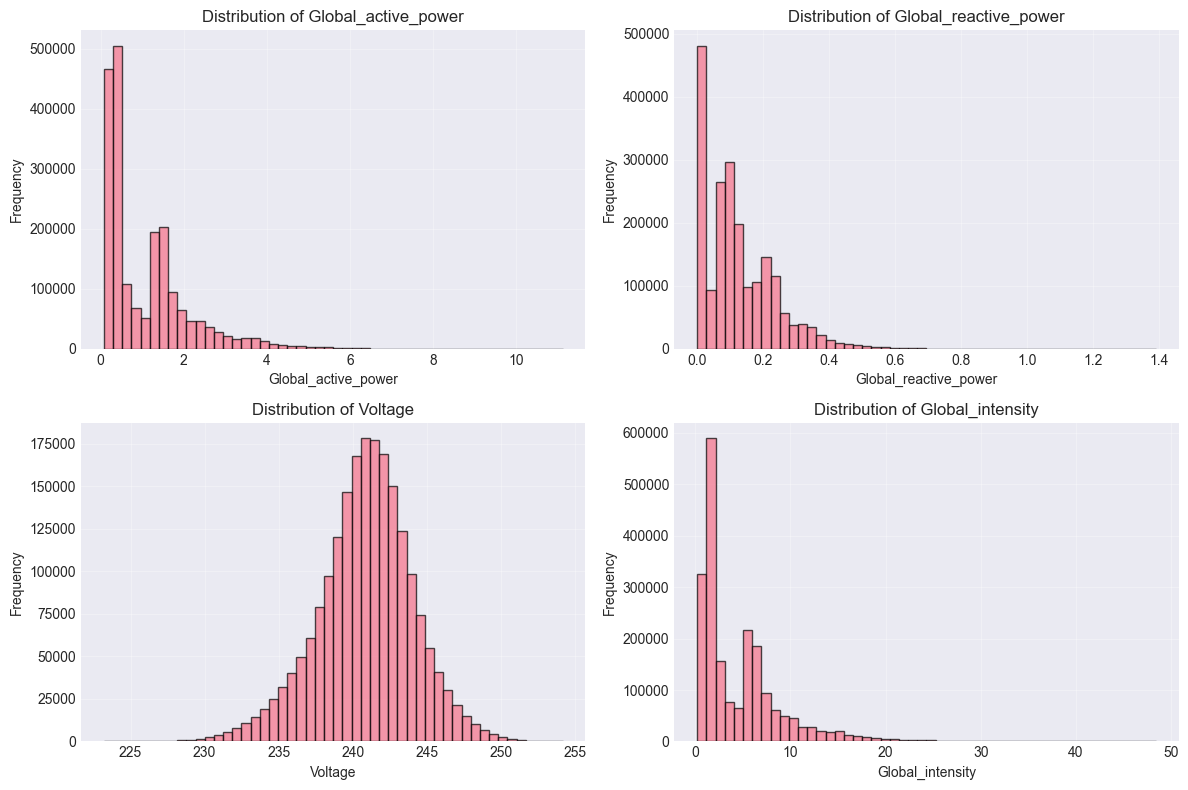

In [27]:
# Distribution plots
columns_to_plot = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity'
]

viz.plot_distribution(
    df_raw,
    columns=columns_to_plot,
    filename='01_distributions.png'
)
plt.show()

## 5. Correlation Analysis

Saved figure to outputs\figures\01_correlation_matrix.png


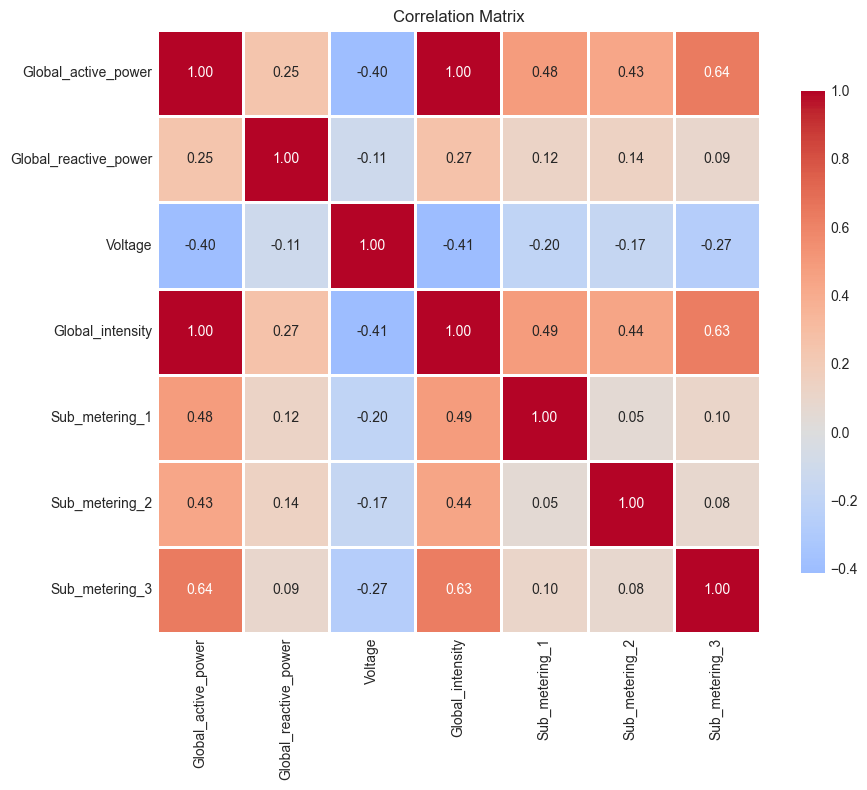

In [28]:
# Correlation matrix
viz.plot_correlation_matrix(
    df_raw,
    filename='01_correlation_matrix.png'
)
plt.show()

## 6. Sub-metering Analysis

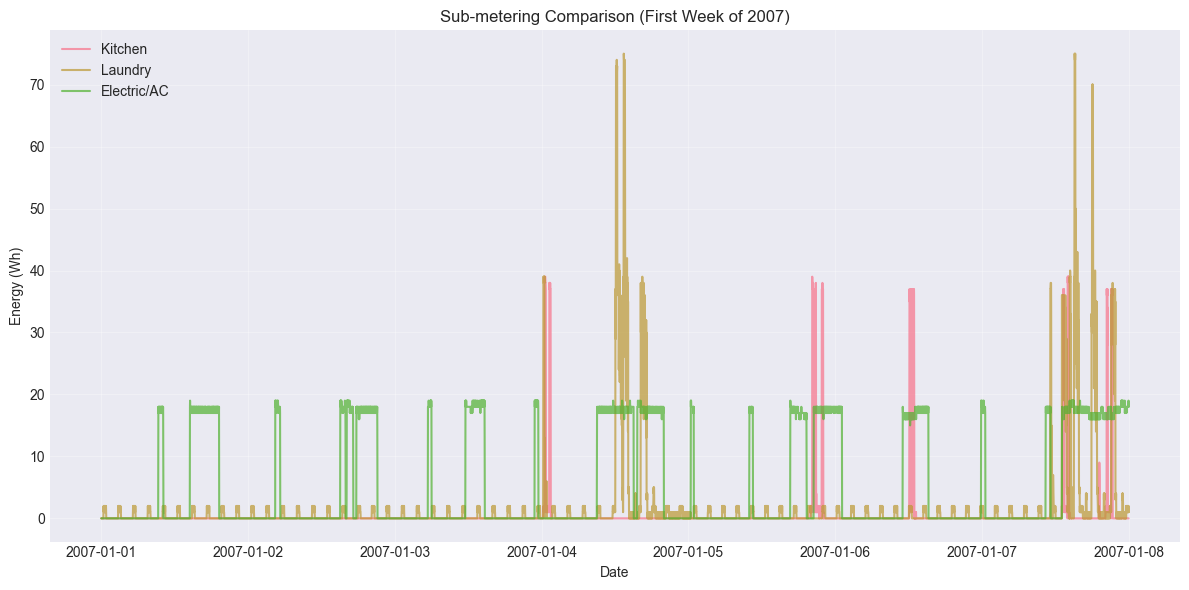

In [29]:
# Compare sub-metering consumption
fig, ax = plt.subplots(figsize=(12, 6))

# Sample one week for visibility
df_week = df_raw['2007-01-01':'2007-01-07']

ax.plot(df_week.index, df_week['Sub_metering_1'], label='Kitchen', alpha=0.7)
ax.plot(df_week.index, df_week['Sub_metering_2'], label='Laundry', alpha=0.7)
ax.plot(df_week.index, df_week['Sub_metering_3'], label='Electric/AC', alpha=0.7)

ax.set_xlabel('Date')
ax.set_ylabel('Energy (Wh)')
ax.set_title('Sub-metering Comparison (First Week of 2007)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/01_submetering_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

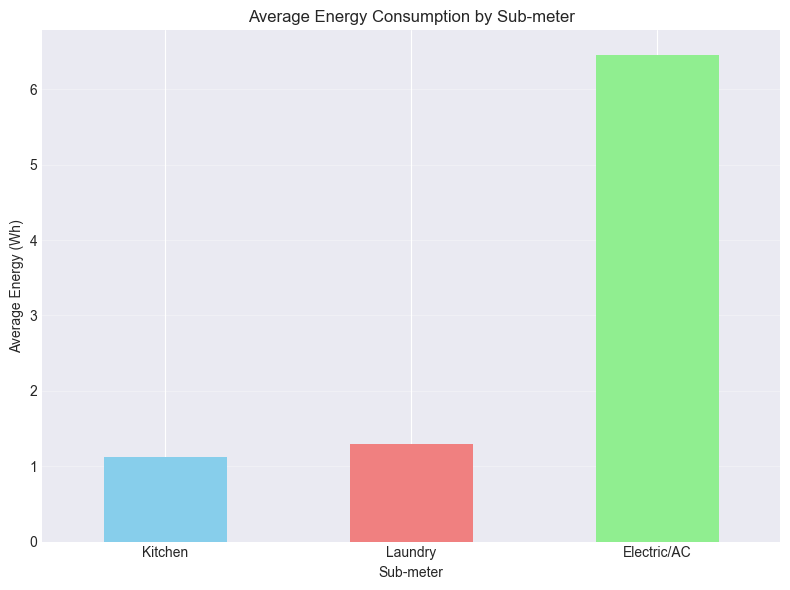

In [30]:
# Average consumption by sub-meter
submetering_avg = df_raw[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].mean()

fig, ax = plt.subplots(figsize=(8, 6))
submetering_avg.plot(kind='bar', ax=ax, color=['skyblue', 'lightcoral', 'lightgreen'])
ax.set_xlabel('Sub-meter')
ax.set_ylabel('Average Energy (Wh)')
ax.set_title('Average Energy Consumption by Sub-meter')
ax.set_xticklabels(['Kitchen', 'Laundry', 'Electric/AC'], rotation=0)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../outputs/figures/01_submetering_average.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Summary and Key Findings

In [31]:
print("=" * 80)
print("KEY FINDINGS FROM EDA")
print("=" * 80)

print("\n1. DATA OVERVIEW:")
print(f"   - Total records: {len(df_raw):,}")
print(f"   - Time span: {df_raw.index.min().date()} to {df_raw.index.max().date()}")
print(f"   - Missing data: {df_raw.isnull().sum().sum():,} values")

print("\n2. CONSUMPTION PATTERNS:")
print(f"   - Average power: {df_raw['Global_active_power'].mean():.2f} kW")
print(f"   - Peak hour: {hourly_avg.idxmax()}:00")
print(f"   - Lowest consumption hour: {hourly_avg.idxmin()}:00")

print("\n3. TEMPORAL PATTERNS:")
print("   - Clear daily seasonality (peak in evening)")
print("   - Weekly patterns visible (weekday vs weekend)")
print("   - Seasonal variations across months")

print("\n4. DATA QUALITY:")
missing_pct = df_raw.isnull().sum().sum() / (len(df_raw) * len(df_raw.columns)) * 100
print(f"   - Overall missing rate: {missing_pct:.2f}%")
print("   - Need preprocessing: missing values, outliers")

print("\n5. NEXT STEPS:")
print("   - Handle missing values")
print("   - Resample to hourly frequency")
print("   - Create features for modeling")
print("   - Detect and handle outliers")

print("=" * 80)

KEY FINDINGS FROM EDA

1. DATA OVERVIEW:
   - Total records: 2,075,259
   - Time span: 2006-12-16 to 2010-11-26
   - Missing data: 181,853 values

2. CONSUMPTION PATTERNS:
   - Average power: 1.09 kW
   - Peak hour: 20:00
   - Lowest consumption hour: 4:00

3. TEMPORAL PATTERNS:
   - Clear daily seasonality (peak in evening)
   - Weekly patterns visible (weekday vs weekend)
   - Seasonal variations across months

4. DATA QUALITY:
   - Overall missing rate: 1.25%
   - Need preprocessing: missing values, outliers

5. NEXT STEPS:
   - Handle missing values
   - Resample to hourly frequency
   - Create features for modeling
   - Detect and handle outliers
